In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time
import tensorflow as tf
import keras
import nltk
from tensorflow.keras.layers import Input,SimpleRNN,TextVectorization,LSTM,Embedding,Dense,GRU,Bidirectional
from tensorflow.keras.models import Sequential
#!pip install gensim
#!pip install keras-tuner
from gensim.models import FastText
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
import re
import keras_tuner as ks
from datasets import load_dataset
from warnings import filterwarnings
filterwarnings('ignore')

2026-05-10 03:43:09.680835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778384589.875610      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778384589.927496      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778384590.353047      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778384590.353097      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778384590.353100      57 computation_placer.cc:177] computation placer alr

## Assignment: RNN-Based Text Classification Using AG News Dataset

## Assignment Title 
### Building and Comparing RNN, LSTM, GRU, and Bi-LSTM Models for News Topic Classification

### Task 1: Load and Explore the Dataset

In [5]:
dataset = load_dataset("ag_news")
print(dataset)
print(type(dataset))

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
<class 'datasets.dataset_dict.DatasetDict'>


In [6]:
df_train=pd.DataFrame(dataset['train'])
df_test=pd.DataFrame(dataset['test'])


In [7]:
df_train.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [8]:
from sklearn.model_selection import train_test_split
x_train=df_train['text']
y_train=df_train['label']
x_test=df_test['text']
y_test=df_test['label']

x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.2,shuffle=True)

print(f'x_train shape : {x_train.shape}')
print(f'y_train shape : {y_train.shape}')

print(f'x_val shape : {x_val.shape}')
print(f'y_val shape : {y_val.shape}')

print(f'x_test shape : {x_test.shape}')
print(f'y_test shape : {y_test.shape}')

x_train shape : (96000,)
y_train shape : (96000,)
x_val shape : (24000,)
y_val shape : (24000,)
x_test shape : (7600,)
y_test shape : (7600,)


In [9]:
x_train

776       Venezuelan President Survives Recall Vote CARA...
106236    DATA VIEW: Australian Economy Puts Brakes On I...
9312      Dozens Charged in Crackdown on Spam and Scams ...
80724     NHL cancels All-Star Weekend The NHL lockout f...
96335     U.S. Commander: N. Korea May Sell Nukes (AP) A...
                                ...                        
30458     Japan OKs Free Trade Agreement With Mexico Jap...
112451    U.S. Video Games Sales Up 11 Pct in Nov. &lt;p...
70693     Eagles 34, Browns 31, OT The only sign that Te...
76090     DreamWorks IPO opens at \$39.50 On Wednesday, ...
112393    Yahoo Searches Desktops, Too Catching up to Go...
Name: text, Length: 96000, dtype: object

In [10]:
for i in range(4):
  print(f'text :{x_train.iloc[i]} \n label :{y_train.iloc[i]}')

text :Venezuelan President Survives Recall Vote CARACAS, Venezuela - President Hugo Chavez appeared to have survived a popular referendum to oust him, according to early results Monday, while Venezuela's opposition swiftly claimed fraud.    Backers of the leftist populist president set off fireworks and began celebrating in the streets of the capital in the pre-dawn darkness upon hearing the news from Francisco Carrasquero, president of the National Elections Council... 
 label :0
text :DATA VIEW: Australian Economy Puts Brakes On In 3Q -2- SYDNEY (Dow Jones)--Australian economic growth slowed sharply in the third quarter, hurt by a sluggish export sector with some offset coming from still buoyant domestic demand. 
 label :2
text :Dozens Charged in Crackdown on Spam and Scams Federal and state law enforcement agencies have quietly arrested or charged dozens of people with crimes related to junk e-mail, identity theft and other online scams. 
 label :2
text :NHL cancels All-Star Weekend

In [11]:
print(f"training unique labels : {y_train.nunique()}")
print(f"testing unique labels : {y_test.nunique()}")
print(f"validation unique labels : {y_val.nunique()}")

training unique labels : 4
testing unique labels : 4
validation unique labels : 4


In [12]:
df_train['label'].value_counts()

label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64

<Axes: xlabel='label'>

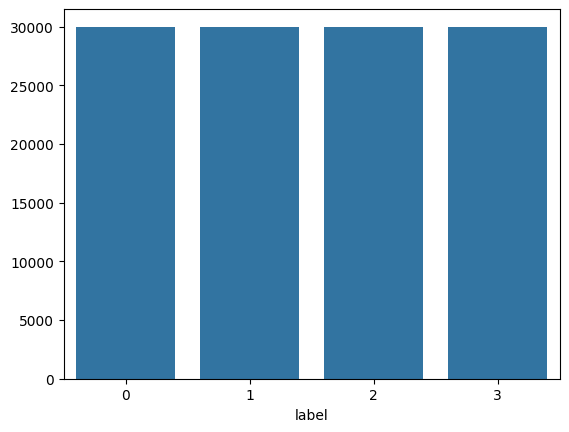

In [13]:
sns.barplot(x=df_train['label'].value_counts().index,y=df_train['label'].value_counts().values)

In [14]:

#tokenization
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^A-Za-z0-9 ]',' ',text)

    return text
tokenized_corpus=[word_tokenize(clean_text(sentence)) for sentence in df_train['text']]
tokenized_corpus[:5]

[['wall',
  'st',
  'bears',
  'claw',
  'back',
  'into',
  'the',
  'black',
  'reuters',
  'reuters',
  'short',
  'sellers',
  'wall',
  'street',
  's',
  'dwindling',
  'band',
  'of',
  'ultra',
  'cynics',
  'are',
  'seeing',
  'green',
  'again'],
 ['carlyle',
  'looks',
  'toward',
  'commercial',
  'aerospace',
  'reuters',
  'reuters',
  'private',
  'investment',
  'firm',
  'carlyle',
  'group',
  'which',
  'has',
  'a',
  'reputation',
  'for',
  'making',
  'well',
  'timed',
  'and',
  'occasionally',
  'controversial',
  'plays',
  'in',
  'the',
  'defense',
  'industry',
  'has',
  'quietly',
  'placed',
  'its',
  'bets',
  'on',
  'another',
  'part',
  'of',
  'the',
  'market'],
 ['oil',
  'and',
  'economy',
  'cloud',
  'stocks',
  'outlook',
  'reuters',
  'reuters',
  'soaring',
  'crude',
  'prices',
  'plus',
  'worries',
  'about',
  'the',
  'economy',
  'and',
  'the',
  'outlook',
  'for',
  'earnings',
  'are',
  'expected',
  'to',
  'hang',
  'ove

In [17]:
for i in range(4):
    print(tokenized_corpus[i])

['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short', 'sellers', 'wall', 'street', 's', 'dwindling', 'band', 'of', 'ultra', 'cynics', 'are', 'seeing', 'green', 'again']
['carlyle', 'looks', 'toward', 'commercial', 'aerospace', 'reuters', 'reuters', 'private', 'investment', 'firm', 'carlyle', 'group', 'which', 'has', 'a', 'reputation', 'for', 'making', 'well', 'timed', 'and', 'occasionally', 'controversial', 'plays', 'in', 'the', 'defense', 'industry', 'has', 'quietly', 'placed', 'its', 'bets', 'on', 'another', 'part', 'of', 'the', 'market']
['oil', 'and', 'economy', 'cloud', 'stocks', 'outlook', 'reuters', 'reuters', 'soaring', 'crude', 'prices', 'plus', 'worries', 'about', 'the', 'economy', 'and', 'the', 'outlook', 'for', 'earnings', 'are', 'expected', 'to', 'hang', 'over', 'the', 'stock', 'market', 'next', 'week', 'during', 'the', 'depth', 'of', 'the', 'summer', 'doldrums']
['iraq', 'halts', 'oil', 'exports', 'from', 'main', 'southern', 'pipel

In [15]:
df_train2=df_train.copy()
df_train2['tokenized']=df_train2['text'].apply(lambda x : (word_tokenize(clean_text(x))))
df_train2['token_length']=df_train2['tokenized'].apply(lambda x : len(x))
df_train2

,text,label,tokenized,token_length
0,Wall St. Bears Claw Back Into the Black (Reute...,2,"[wall, st, bears, claw, back, into, the, black...",24
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,"[carlyle, looks, toward, commercial, aerospace...",39
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,"[oil, and, economy, cloud, stocks, outlook, re...",38
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,"[iraq, halts, oil, exports, from, main, southe...",38
4,"Oil prices soar to all-time record, posing new...",2,"[oil, prices, soar, to, all, time, record, pos...",37
...,...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,"[pakistan, s, musharraf, says, won, t, quit, a...",40
119996,Renteria signing a top-shelf deal Red Sox gene...,1,"[renteria, signing, a, top, shelf, deal, red, ...",61
119997,Saban not going to Dolphins yet The Miami Dolp...,1,"[saban, not, going, to, dolphins, yet, the, mi...",44
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,"[today, s, nfl, games, pittsburgh, at, ny, gia...",70


In [18]:
iqr=df_train2['token_length'].quantile(0.75)+1.5*(df_train2['token_length'].quantile(0.75)-df_train2['token_length'].quantile(0.25))

<Axes: xlabel='token_length', ylabel='Count'>

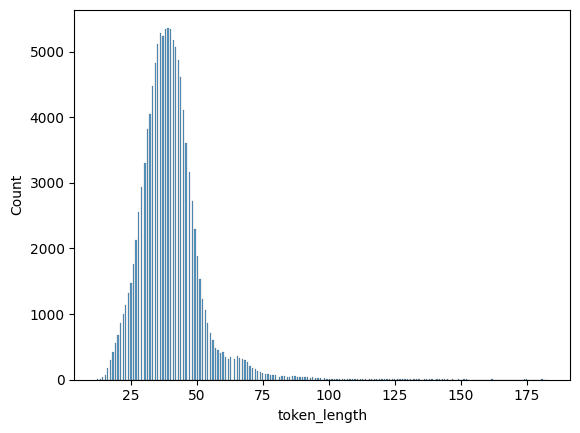

In [19]:
sns.histplot(df_train2['token_length'])

In [20]:
print(df_train2['token_length'].quantile(0.25))
print(df_train2['token_length'].quantile(0.75))

33.0
45.0


In [21]:
max_sentence_len=((int(iqr/10))+1)*10

In [22]:
vectorize_layer=tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',
    max_tokens=20000,
    output_mode='int',
    output_sequence_length=max_sentence_len,
)

training_sentences=df_train2['text']
vectorize_layer.adapt(training_sentences)

fasttext_model=FastText(sentences=tokenized_corpus,vector_size=100,window=7,min_count=1,workers=4)

vocab=vectorize_layer.get_vocabulary()
num_tokens=len(vocab)
embedding_dim=100
embedding_matrix=np.zeros((num_tokens,embedding_dim))

for i,word in enumerate(vocab):
        embedding_matrix[i]=fasttext_model.wv[word]

I0000 00:00:1778384903.543101      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [23]:
x_train_vector=vectorize_layer(x_train).numpy()
x_val_vector=vectorize_layer(x_val).numpy()
x_test_vector=vectorize_layer(x_test).numpy()
y_train_vector=y_train.values
y_val_vector=y_val.values
y_test_vector=y_test.values
print(f"x_train shape : {x_train.shape}")
print(f"x_val shape : {x_val.shape}")
print(f"x_test shape : {x_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_val shape : {y_val.shape}")
print(f"y_test shape : {y_test.shape}")

x_train shape : (96000,)
x_val shape : (24000,)
x_test shape : (7600,)
y_train shape : (96000,)
y_val shape : (24000,)
y_test shape : (7600,)


In [25]:
x_train_vector

array([[4342,   68, 7167, ...,    0,    0,    0],
       [ 244, 1660,  392, ...,    0,    0,    0],
       [1809,  791,    6, ...,    0,    0,    0],
       ...,
       [1353, 2619, 2531, ...,    0,    0,    0],
       [4679, 1619, 1600, ...,    0,    0,    0],
       [ 671, 5774, 4770, ...,    0,    0,    0]])

In [30]:
x_train.values

array(["Venezuelan President Survives Recall Vote CARACAS, Venezuela - President Hugo Chavez appeared to have survived a popular referendum to oust him, according to early results Monday, while Venezuela's opposition swiftly claimed fraud.    Backers of the leftist populist president set off fireworks and began celebrating in the streets of the capital in the pre-dawn darkness upon hearing the news from Francisco Carrasquero, president of the National Elections Council...",
       'DATA VIEW: Australian Economy Puts Brakes On In 3Q -2- SYDNEY (Dow Jones)--Australian economic growth slowed sharply in the third quarter, hurt by a sluggish export sector with some offset coming from still buoyant domestic demand.',
       'Dozens Charged in Crackdown on Spam and Scams Federal and state law enforcement agencies have quietly arrested or charged dozens of people with crimes related to junk e-mail, identity theft and other online scams.',
       ...,
       'Eagles 34, Browns 31, OT The only s

#### Brief explanation of why tokenization and padding are needed?
- Tokenization : Raw text cannot be processed directly by neural networks; they only understand
    numbers.it Breaks down raw text into smaller units called tokens (words, subwords, or characters) and maps each token to a unique numerical ID. It creates a standardized vocabulary and allows the model to interpret the text mathematically.
- padding : Deep learning models require batches of data to have a "rectangular" or consistent shape to process them efficiently.it Adds special, meaningless tokens (usually 0) to shorter sentences to match the length of the longest sentence in a batch.Without padding, the model cannot perform matrix multiplication on batches of data, which is necessary for training on GPUs.


### Simple RNN

In [31]:
class SRNN_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      SimpleRNN(units=512,return_sequences=False),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_srnn.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


srnn_model=SRNN_model()
hp=ks.HyperParameters()
srn_model=srnn_model.build(hp)
print(srn_model.summary())

srnn_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=SRNN_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=SRNN_model()
best_hp=tuner.get_best_hyperparameters()[0]
srnn_model=hypermodel.build(best_hp)
srnn_history=hypermodel.fit(best_hp,srnn_model,x_train.values,y_train.values)


srnn_end_time=time.time()
srnn_total_time=(srnn_end_time-srnn_start_time)/60
print(f"total_time_taken: {srnn_total_time}")

Trial 2 Complete [00h 13m 56s]
val_accuracy: 0.8536666631698608

Best val_accuracy So Far: 0.8536666631698608
Total elapsed time: 01h 03m 14s
Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6714 - loss: 0.9002
Epoch 1: val_accuracy improved from 0.01000 to 0.70627, saving model to best_srnn.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 100ms/step - accuracy: 0.6714 - loss: 0.9002 - val_accuracy: 0.7063 - val_loss: 0.7836
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7067 - loss: 0.8150
Epoch 2: val_accuracy did not improve from 0.70627
981/981 ━━━━━━━━━━━━━━━━━━━━ 93s 95ms/step - accuracy: 0.7067 - loss: 0.8151 - val_accuracy: 0.5997 - val_loss: 0.9777
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6048 - loss: 0.9853
Epoch 3: val_accuracy improved from 0.70627 to 0.75568, saving model to best_srnn.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 97s 99ms/step - accuracy: 0.6049 - loss: 0.9853 - val_accuracy: 0.7557 - val_loss: 0.7128
Epoch 4/20


In [32]:
srnn_train_loss,srnn_train_acc=srnn_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {srnn_train_acc}")
print(f"train Loss: {srnn_train_loss}")

srnn_val_loss,srnn_val_acc=srnn_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {srnn_val_acc}")
print(f"Val Loss: {srnn_val_loss}")

srnn_test_loss,srnn_test_acc=srnn_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {srnn_test_acc}")
print(f"Test Loss: {srnn_test_loss}")

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 88s 29ms/step - accuracy: 0.7074 - loss: 0.7879
Train Accuracy: 0.7075833082199097
train Loss: 0.7843915820121765
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7150 - loss: 0.7711
Val Accuracy: 0.7097083330154419
Val Loss: 0.781205415725708
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.6860 - loss: 0.8195
Test Accuracy: 0.696052610874176
Test Loss: 0.8136043548583984


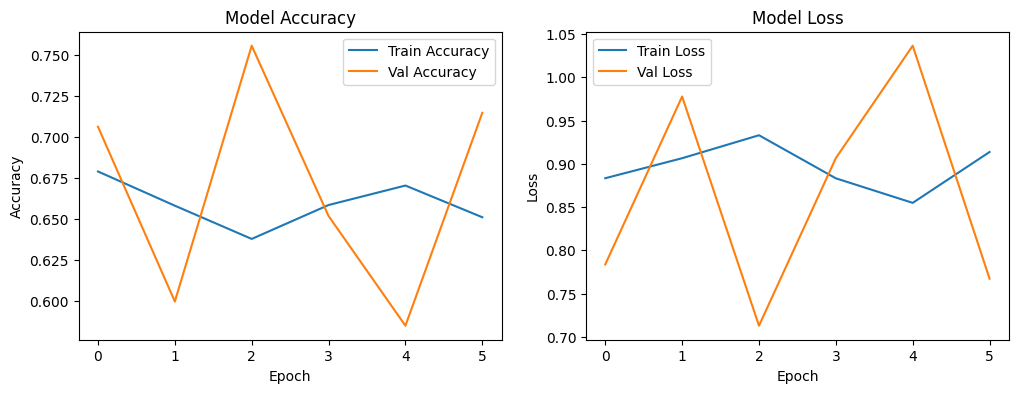

In [33]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(srnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(srnn_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(srnn_history.history['loss'], label='Train Loss')
plt.plot(srnn_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [ ]:
from sklearn.metrics import classification_report
srnn_pred=np.argmax(srnn_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,srnn_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step
              precision    recall  f1-score   support

           0       0.72      0.80      0.76      1900
           1       0.92      0.80      0.85      1900
           2       0.55      0.77      0.64      1900
           3       0.66      0.41      0.51      1900

    accuracy                           0.70      7600
   macro avg       0.71      0.70      0.69      7600
weighted avg       0.71      0.70      0.69      7600



In [35]:
comp_table=pd.DataFrame({'metrics':[
                          'Training_Accuracy',
                         'Validation_Accuracy',
                         'Test_Accuracy',
                        'Training_Time(Minutes)',
                          'key Observation']})
comp_table['SimpleRNN']=[srnn_train_acc,srnn_val_acc,srnn_test_acc,srnn_total_time,'']


In [36]:
comp_table

,metrics,SimpleRNN
0,Training_Accuracy,0.707583
1,Validation_Accuracy,0.709708
2,Test_Accuracy,0.696053
3,Training_Time(Minutes),72.829653
4,key Observation,


### KEY_OBSERVATION

- Validation Jitter: The validation accuracy (orange line) swings wildly between roughly 58% and 76% within just 5 epochs.
- Divergence: At several points, the training and validation metrics move in opposite directions. This suggests the model is struggling to find a stable local minimum and the learning rate might be too high.
- The Strongest (Class 1): Boasts a high precision of 0.92. If the model says it's Class 1, it’s almost certainly right.

- The Weakest (Class 3): This is a major pain point. It has a recall of only 0.41, meaning the model misses nearly 60% of actual Class 3 instances.

- The "Confusion" (Class 2): While it has decent recall (0.77), its precision is quite low (0.55), suggesting the model over-predicts Class 2, leading to many false positives.

-The erratic loss curves and the plateau in accuracy are classic symptoms of
    - Vanishing/Exploding Gradient Problem
 
- Time Cost: The training time is recorded at approximately 72.8 minutes. Given the high volatility in the loss curves and a final accuracy of ~70%, this is a relatively long training time for a SimpleRNN for these results

### LSTM

In [37]:
class LSTM_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      LSTM(units=512,return_sequences=False,dropout=0.2),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_lstm.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


ls_model=LSTM_model()
hp=ks.HyperParameters()
lstm_model=ls_model.build(hp)
print(srn_model.summary())

lstm_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=LSTM_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=LSTM_model()
best_hp=tuner.get_best_hyperparameters()[0]
lstm_model=hypermodel.build(best_hp)
lstm_history=hypermodel.fit(best_hp,lstm_model,x_train.values,y_train.values)


lstm_end_time=time.time()
lstm_total_time=(lstm_end_time-lstm_start_time)/60
print(f"total_time_taken: {lstm_total_time}")

Trial 2 Complete [00h 02m 58s]
val_accuracy: 0.9050833582878113

Best val_accuracy So Far: 0.9050833582878113
Total elapsed time: 00h 09m 10s
Epoch 1/15
1291/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7929 - loss: 4.3996
Epoch 1: val_accuracy improved from 0.01000 to 0.87715, saving model to best_lstm.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.7930 - loss: 4.3943 - val_accuracy: 0.8771 - val_loss: 0.4679
Epoch 2/15
1290/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8636 - loss: 0.4872
Epoch 2: val_accuracy improved from 0.87715 to 0.88409, saving model to best_lstm.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8636 - loss: 0.4871 - val_accuracy: 0.8841 - val_loss: 0.4120
Epoch 3/15
1290/1293 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8775 - loss: 0.4210
Epoch 3: val_accuracy improved from 0.88409 to 0.89299, saving model to best_lstm.keras
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8775 - loss: 0.4209 - val_

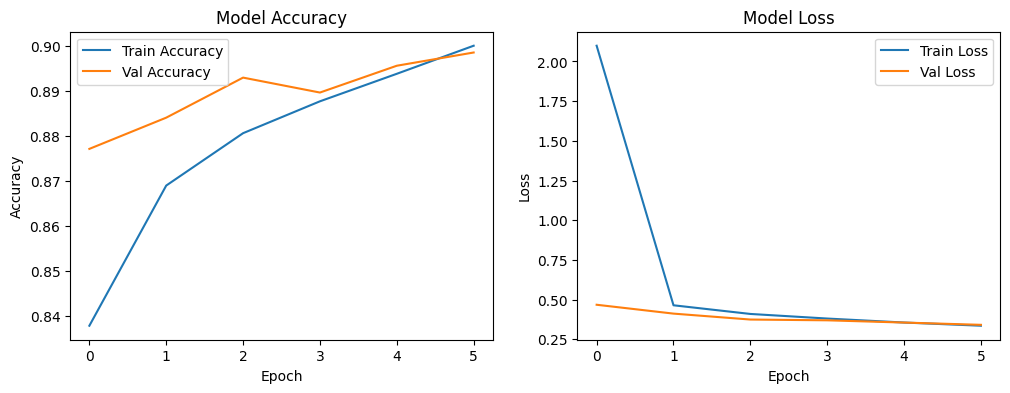

In [42]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [43]:
lstm_train_loss,lstm_train_acc=lstm_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {lstm_train_acc}")
print(f"train Loss: {lstm_train_loss}")

lstm_val_loss,lstm_val_acc=lstm_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {lstm_val_acc}")
print(f"Val Loss: {lstm_val_loss}")

lstm_test_loss,lstm_test_acc=lstm_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {lstm_test_acc}")
print(f"Test Loss: {lstm_test_loss}")



3000/3000 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8763 - loss: 0.4702
Train Accuracy: 0.8783749938011169
train Loss: 0.46583569049835205
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8779 - loss: 0.4634
Val Accuracy: 0.877916693687439
Val Loss: 0.4680674374103546
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8666 - loss: 0.5038
Test Accuracy: 0.871184229850769
Test Loss: 0.48592910170555115


In [40]:
lstm_pred=np.argmax(lstm_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,lstm_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1900
           1       0.93      0.94      0.94      1900
           2       0.85      0.81      0.83      1900
           3       0.80      0.88      0.84      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600



In [41]:
comp_table['LSTM']=[lstm_train_acc,lstm_val_acc,lstm_test_acc,lstm_total_time,'']
comp_table

,metrics,SimpleRNN,LSTM
0,Training_Accuracy,0.707583,0.878375
1,Validation_Accuracy,0.709708,0.877917
2,Test_Accuracy,0.696053,0.871184
3,Training_Time(Minutes),72.829653,11.638385
4,key Observation,,


### KEY_OBSERVATION COMPARISON: SRNN VS LSTM

- Accuracy Boost: The LSTM achieved a test accuracy of 87%, compared to the SimpleRNN's 69%. This is an absolute improvement of roughly 18%.
- Model Stability: Unlike the erratic, zig-zagging curves of the SimpleRNN, the LSTM accuracy and loss plots are smooth and converges. The training and validation lines track each other closely, which indicates a very healthy learning process.
- Recall Restoration: With the LSTM, Class 3 recall has jumped to 0.88.
- Precision/Recall Balance: The LSTM shows high F1-scores (0.83 to 0.94) across all four classes. It no longer struggles to distinguish between specific categories, likely because the LSTM's "gates" are better at remembering long-term context in the text that a SimpleRNN forgets.
- LSTM is ~6x Faster: Even though LSTMs are mathematically more complex than SimpleRNNs, your LSTM finished training in 11.6 minutes, while the SimpleRNN took 72.8 minutes.Because the LSTM is more stable and has a better gradient flow, it reached a high accuracy much faster. The SimpleRNN was likely "oscillating" and struggling to converge, requiring more computational effort to achieve much poorer results.



### GRU

In [44]:
class GRU_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      GRU(units=512,return_sequences=False,dropout=0.2),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_gru.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


grux_model=GRU_model()
hp=ks.HyperParameters()
gru_model=grux_model.build(hp)
print(gru_model.summary())

gru_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=GRU_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=GRU_model()
best_hp=tuner.get_best_hyperparameters()[0]
gru_model=hypermodel.build(best_hp)
gru_history=hypermodel.fit(best_hp,gru_model,x_train.values,y_train.values)


gru_end_time=time.time()
gru_total_time=(gru_end_time-gru_start_time)/60
print(f"total_time_taken: {gru_total_time}")

Trial 2 Complete [00h 01m 18s]
val_accuracy: 0.8997499942779541

Best val_accuracy So Far: 0.9104999899864197
Total elapsed time: 00h 06m 23s
Epoch 1/5
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8015 - loss: 0.5762
Epoch 1: val_accuracy improved from 0.01000 to 0.89125, saving model to best_gru.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 53s 10ms/step - accuracy: 0.8016 - loss: 0.5762 - val_accuracy: 0.8913 - val_loss: 0.3396
Epoch 2/5
5397/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8833 - loss: 0.3503
Epoch 2: val_accuracy improved from 0.89125 to 0.90240, saving model to best_gru.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - accuracy: 0.8833 - loss: 0.3503 - val_accuracy: 0.9024 - val_loss: 0.2949
Epoch 3/5
5396/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8961 - loss: 0.3035
Epoch 3: val_accuracy improved from 0.90240 to 0.90833, saving model to best_gru.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 51s 9ms/step - accuracy: 0.8961 - loss: 0.3035 - val_accuracy: 0

In [45]:
gru_train_loss,gru_train_acc=gru_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {gru_train_acc}")
print(f"train Loss: {gru_train_loss}")

gru_val_loss,gru_val_acc=gru_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {gru_val_acc}")
print(f"Val Loss: {gru_val_loss}")

gru_test_loss,gru_test_acc=gru_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {gru_test_acc}")
print(f"Test Loss: {gru_test_loss}")

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.8920 - loss: 0.3340
Train Accuracy: 0.8959791660308838
train Loss: 0.32278361916542053
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8922 - loss: 0.3342
Val Accuracy: 0.8927500247955322
Val Loss: 0.3382483422756195
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8824 - loss: 0.3700
Test Accuracy: 0.8881579041481018
Test Loss: 0.35361248254776


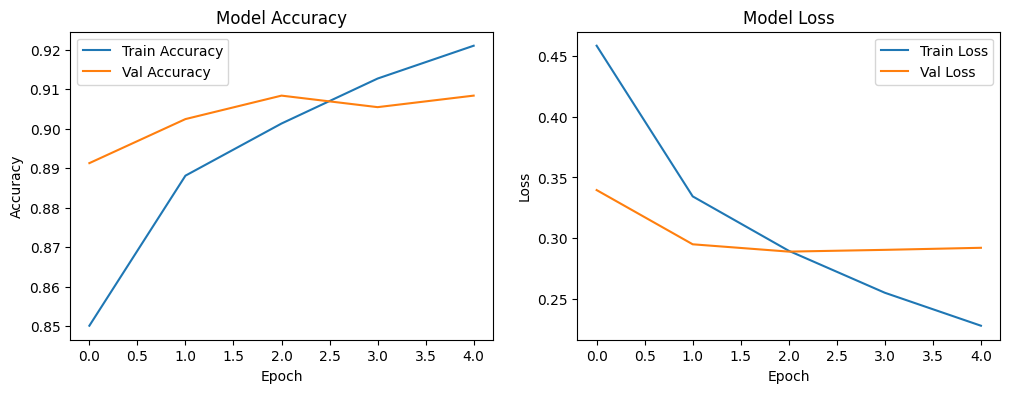

In [46]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(gru_history.history['accuracy'], label='Train Accuracy')
plt.plot(gru_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gru_history.history['loss'], label='Train Loss')
plt.plot(gru_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [47]:
gru_pred=np.argmax(gru_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,gru_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.93      0.86      0.90      1900
           1       0.92      0.98      0.95      1900
           2       0.85      0.84      0.84      1900
           3       0.86      0.87      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [48]:
comp_table['GRU']=[gru_train_acc,gru_val_acc,gru_test_acc,gru_total_time,'']
comp_table

,metrics,SimpleRNN,LSTM,GRU
0,Training_Accuracy,0.707583,0.878375,0.895979
1,Validation_Accuracy,0.709708,0.877917,0.89275
2,Test_Accuracy,0.696053,0.871184,0.888158
3,Training_Time(Minutes),72.829653,11.638385,10.572474
4,key Observation,,,


### KEY OBSERVATION

- Accuracy: GRU achieved the highest test accuracy at 88.8%, slightly edgeing out the LSTM (87.1%) and significantly outperforming the SimpleRNN (69.6%)
  
- Balanced Class Performance: The classification report for the GRU shows exceptional balance. Every single class now has an F1-score between 0.84 and 0.95. The model is no longer "guessing" or favoring one class over another.

- GRU clocked in at 10.57 minutes, compared to LSTM's 11.6 minutes.GRUs have a simpler internal structure (two gates: reset and update) compared to LSTMs (three gates: input, forget, and output). This reduction in parameters allows the GRU to converge faster while maintaining—or in this case, improving—performance on your specific text dataset.

- Like the LSTM, the GRU curves are smooth, indicating stable weight updates and a well-tuned learning rate.

### BI-LSTM

In [49]:
class BILSTM_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      Bidirectional(LSTM(units=512,return_sequences=False,dropout=0.2)),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_bilstm.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


bi_lstm_model=BILSTM_model()
hp=ks.HyperParameters()
bilstm_model=bi_lstm_model.build(hp)
print(bilstm_model.summary())

bilstm_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=BILSTM_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=BILSTM_model()
best_hp=tuner.get_best_hyperparameters()[0]
bilstm_model=hypermodel.build(best_hp)
bilstm_history=hypermodel.fit(best_hp,bilstm_model,x_train.values,y_train.values)


bilstm_end_time=time.time()
bilstm_total_time=(bilstm_end_time-bilstm_start_time)/60
print(f"total_time_taken: {bilstm_total_time}")

Trial 2 Complete [00h 03m 28s]
val_accuracy: 0.9009166955947876

Best val_accuracy So Far: 0.9087499976158142
Total elapsed time: 00h 13m 56s
Epoch 1/5
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8392 - loss: 0.5019
Epoch 1: val_accuracy improved from 0.01000 to 0.89333, saving model to best_bilstm.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 111s 20ms/step - accuracy: 0.8392 - loss: 0.5019 - val_accuracy: 0.8933 - val_loss: 0.3399
Epoch 2/5
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8878 - loss: 0.3367
Epoch 2: val_accuracy improved from 0.89333 to 0.89927, saving model to best_bilstm.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 108s 20ms/step - accuracy: 0.8878 - loss: 0.3367 - val_accuracy: 0.8993 - val_loss: 0.3131
Epoch 3/5
5399/5400 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9028 - loss: 0.2837
Epoch 3: val_accuracy improved from 0.89927 to 0.90448, saving model to best_bilstm.keras
5400/5400 ━━━━━━━━━━━━━━━━━━━━ 108s 20ms/step - accuracy: 0.9028 - loss: 0.2837 

In [50]:
bilstm_train_loss,bilstm_train_acc=bilstm_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {bilstm_train_acc}")
print(f"train Loss: {bilstm_train_loss}")

bilstm_val_loss,bilstm_val_acc=bilstm_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {bilstm_val_acc}")
print(f"Val Loss: {bilstm_val_loss}")

bilstm_test_loss,bilstm_test_acc=bilstm_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {bilstm_test_acc}")
print(f"Test Loss: {bilstm_test_loss}")




3000/3000 ━━━━━━━━━━━━━━━━━━━━ 27s 9ms/step - accuracy: 0.8933 - loss: 0.3270
Train Accuracy: 0.8975937366485596
train Loss: 0.31547465920448303
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8950 - loss: 0.3278
Val Accuracy: 0.893625020980835
Val Loss: 0.33437874913215637
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8827 - loss: 0.3573
Test Accuracy: 0.8882894515991211
Test Loss: 0.34454843401908875


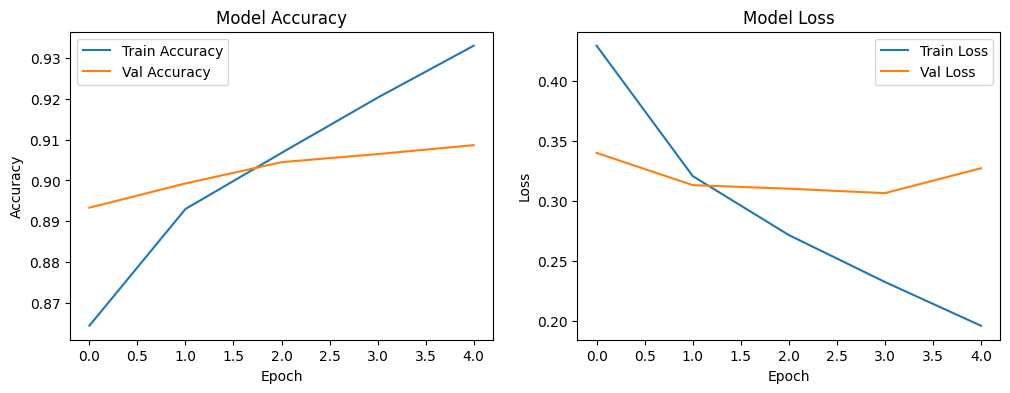

In [51]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(bilstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(bilstm_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bilstm_history.history['loss'], label='Train Loss')
plt.plot(bilstm_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [52]:
bilstm_pred=np.argmax(bilstm_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,bilstm_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      1900
           1       0.94      0.97      0.95      1900
           2       0.85      0.85      0.85      1900
           3       0.83      0.89      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [53]:
comp_table['BILSTM']=[bilstm_train_acc,bilstm_val_acc,bilstm_test_acc,bilstm_total_time,'']
comp_table

,metrics,SimpleRNN,LSTM,GRU,BILSTM
0,Training_Accuracy,0.707583,0.878375,0.895979,0.897594
1,Validation_Accuracy,0.709708,0.877917,0.89275,0.893625
2,Test_Accuracy,0.696053,0.871184,0.888158,0.888289
3,Training_Time(Minutes),72.829653,11.638385,10.572474,23.027933
4,key Observation,,,,


### KEY OBSERVATION

- While BiLSTMs are theoretically superior because they process text in both directions, for this specific dataset, the extra "backward" context didn't provide a significant boost over the GRU.
- At 23.02 minutes, the BiLSTM took more than double the time of the GRU (10.57m) and LSTM (11.63m).This is expected, as a BiLSTM essentially trains two separate hidden layers  and then concatenates them. this twice the work for a marginal gain in accuracy.
- Divergence: The Training Accuracy is climbing steeply toward 93%, but the Validation Accuracy is flattening out around 90%.

- Loss Curve: More concerning is the Model Loss graph—the Validation Loss (orange) has actually started to increase after epoch 3, while the Training Loss continues to drop.

### GRU with gradient clipping

In [66]:
class GRUgc_model(ks.HyperModel):
  def build(self,hp):

    reg_type=hp.Choice(f'reg_type',['l1','l2','l1_l2','None'])
    if reg_type=='l1':
      reg=keras.regularizers.L1(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l2':
      reg=keras.regularizers.L2(
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    elif reg_type=='l1_l2':
      reg=keras.regularizers.L1L2(
          l1=hp.Float(f'l1',min_value=1e-4,max_value=1e-3,sampling='log'),
          l2=hp.Float(f'l2',min_value=1e-4,max_value=1e-3,sampling='log')
      )
    else:
      reg=None
    model=Sequential([
      Input(shape=(1,),dtype=tf.string),
      vectorize_layer,
      tf.keras.layers.Embedding(
          input_dim=num_tokens,
          output_dim=embedding_dim,
          embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
          trainable=False,
          mask_zero=True
      ),
      GRU(units=512,return_sequences=False,dropout=0.2),
      tf.keras.layers.Dense(512,activation='relu',kernel_regularizer=reg),
      tf.keras.layers.Dense(len(set(dataset['train']['label'])),activation='softmax')
      ])
    learning_rate=hp.Float('learning_rate',min_value=1e-4,max_value=1e-1,sampling='log')
    clip_norm=hp.Float('clipnorm',min_value=0.5,max_value=1.0,sampling='log')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate,clipnorm=clip_norm), #Applying Gradient clipping
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


  def fit(self,hp,model,x,y,*args,**kwargs):
    callbacks=kwargs.pop('callbacks',[])
    model_checkpoint=keras.callbacks.ModelCheckpoint(
        filepath='best_grugc.keras',
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='auto',
        save_freq='epoch',
        initial_value_threshold=0.01
    )
    early_stopping=keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        min_delta=0.1,
        patience=5,
        verbose=1,
        mode='auto',
        restore_best_weights=True,
        start_from_epoch=0
    )
    callbacks.append(model_checkpoint)
    callbacks.append(early_stopping)
    return model.fit(
        x=x,
        y=y,
        *args,
        batch_size=hp.Int('batch_size',min_value=16,max_value=512,step=16),
        epochs=hp.Int('epochs',min_value=5,max_value=25,step=5),
        verbose='auto',
        callbacks=[model_checkpoint,early_stopping],
        validation_split=hp.Float('validation_split',min_value=0.1,max_value=0.25,sampling='linear'),
        shuffle=hp.Boolean('shuffle'),
        **kwargs
    )


grugcx_model=GRUgc_model()
hp=ks.HyperParameters()
grugc_model=grugcx_model.build(hp)
print(grugc_model.summary())

grugc_start_time=time.time()

tuner=ks.RandomSearch(
    hypermodel=GRUgc_model(),
    objective='val_accuracy',
    max_trials=2,
    executions_per_trial=1,
    overwrite=True,
    directory='tuned',
    project_name='news_classification'
)
tuner.search(x_train.values,y_train.values,validation_data=(x_val.values,y_val.values))


hypermodel=GRUgc_model()
best_hp=tuner.get_best_hyperparameters()[0]
grugc_model=hypermodel.build(best_hp)
grugc_history=hypermodel.fit(best_hp,gru_model,x_train.values,y_train.values)


grugc_end_time=time.time()
grugc_total_time=(grugc_end_time-grugc_start_time)/60
print(f"total_time_taken: {grugc_total_time}")

Trial 2 Complete [00h 01m 13s]
val_accuracy: 0.902999997138977

Best val_accuracy So Far: 0.902999997138977
Total elapsed time: 00h 06m 02s
Epoch 1/15
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9068 - loss: 0.2717
Epoch 1: val_accuracy improved from 0.01000 to 0.91918, saving model to best_grugc.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9068 - loss: 0.2717 - val_accuracy: 0.9192 - val_loss: 0.2453
Epoch 2/15
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9119 - loss: 0.2548
Epoch 2: val_accuracy improved from 0.91918 to 0.92028, saving model to best_grugc.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9119 - loss: 0.2548 - val_accuracy: 0.9203 - val_loss: 0.2433
Epoch 3/15
207/208 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9143 - loss: 0.2481
Epoch 3: val_accuracy did not improve from 0.92028
208/208 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9143 - loss: 0.2482 - val_accuracy: 0.9201 - val_loss: 0.2425
Epoch 4/15
207

In [67]:
grugc_train_loss,grugc_train_acc=grugc_model.evaluate(x_train.values,y_train.values)
print(f"Train Accuracy: {grugc_train_acc}")
print(f"train Loss: {grugc_train_loss}")

grugc_val_loss,grugc_val_acc=grugc_model.evaluate(x_val.values,y_val.values)
print(f"Val Accuracy: {grugc_val_acc}")
print(f"Val Loss: {grugc_val_loss}")

grugc_test_loss,grugc_test_acc=grugc_model.evaluate(x_test.values,y_test.values)
print(f"Test Accuracy: {grugc_test_acc}")
print(f"Test Loss: {grugc_test_loss}")

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.2585 - loss: 1.3866
Train Accuracy: 0.2600937485694885
train Loss: 1.3867332935333252
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2559 - loss: 1.3874
Val Accuracy: 0.2590000033378601
Val Loss: 1.3853693008422852
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2519 - loss: 1.3890
Test Accuracy: 0.2605263292789459
Test Loss: 1.382683277130127


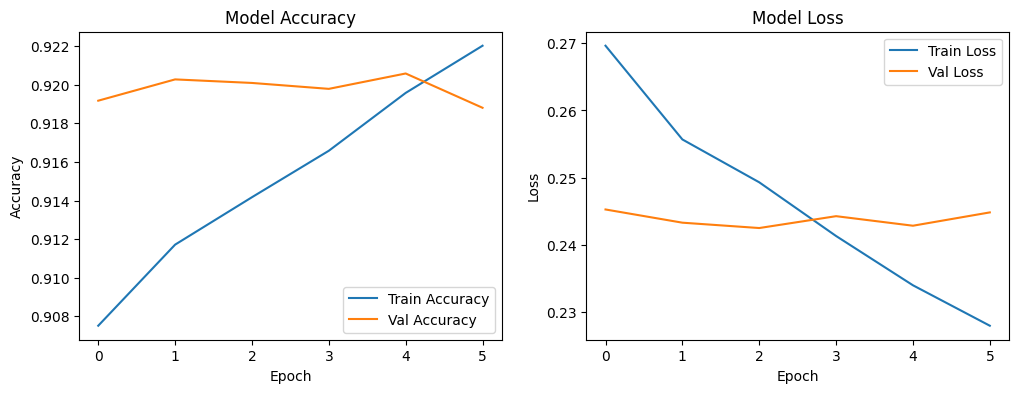

In [68]:
# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(grugc_history.history['accuracy'], label='Train Accuracy')
plt.plot(grugc_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(grugc_history.history['loss'], label='Train Loss')
plt.plot(grugc_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


In [69]:
grugc_pred=np.argmax(grugc_model.predict(x_test.values),axis=1)
print(classification_report(y_test.values,grugc_pred))

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.25      0.29      0.27      1900
           1       0.58      0.06      0.11      1900
           2       0.27      0.58      0.36      1900
           3       0.21      0.10      0.14      1900

    accuracy                           0.26      7600
   macro avg       0.32      0.26      0.22      7600
weighted avg       0.32      0.26      0.22      7600



In [71]:
comp_table['GRUgc']=[grugc_train_acc,grugc_val_acc,grugc_test_acc,grugc_total_time,'']
comp_table

,metrics,SimpleRNN,LSTM,GRU,BILSTM,GRUgc
0,Training_Accuracy,0.707583,0.878375,0.895979,0.897594,0.260094
1,Validation_Accuracy,0.709708,0.877917,0.89275,0.893625,0.259
2,Test_Accuracy,0.696053,0.871184,0.888158,0.888289,0.260526
3,Training_Time(Minutes),72.829653,11.638385,10.572474,23.027933,6.937014
4,key Observation,,,,,


### KEY OBSERVATION

Without Gradient Clipping (GRU)
    
    - Performance: This model was highly successful, reaching nearly 89% test accuracy. It successfully captured the linguistic patterns of the dataset.
    
    - Convergence: The model converged to a stable, high-accuracy state. Based on your earlier plots, the loss curve was smooth, suggesting that for this specific task, the gradients were already well-behaved and did not "explode."
    
    - Effectiveness: The "natural" gradients were large enough to allow the model to learn complex relationships between words and labels.

With Gradient Clipping (GRUgc)

    - Performance: This model failed to learn, performing at roughly 26% accuracy, which is near-random guessing for a 4-class problem.

    - Convergence: While the training time was faster (6.93 minutes), it was essentially a "fast-track to failure." The model never moved past the initial baseline performance.

    - Suffocation Effect: In your case, the gradient clipping acted as a "bottleneck" rather than a safety net. Because the clipnorm was likely set too low, the weight updates were so small that the model could not navigate the loss landscape to find a better solution.


yes, it made the training "stable" in the sense that there were no erratic spikes in loss, but it was unproductive stability.

    - Stability vs. Learning: Without clipping, the GRU was already stable and achieved high accuracy. With clipping, the training became "dead-flat"—it was so stable that it never moved.

    - Conclusion: For your specific dataset and architecture, gradient clipping was not beneficial. It transformed a high-performing model into a non-functional one because the gradients needed to reach 89% accuracy were "chopped off" by the clipping threshold.

1. Which model performed best?
 - The GRU (standard) model performed the best overall. It achieved a Test Accuracy of 88.82%, which was marginally higher than the standard LSTM and Bi-LSTM models while maintaining superior computational efficiency.

2. Did LSTM or GRU perform better than Simple RNN?
 - Yes, significantly. The Simple RNN achieved a test accuracy of only 69.61%, whereas the LSTM and GRU both crossed the 87% mark. This represents a nearly 20% improvement in accuracy. The gated architectures of LSTM and GRU successfully addressed the Vanishing Gradient problem, allowing the model to capture long-term dependencies in the text that the Simple RNN could not.

3. Did Bi-LSTM improve classification performance?
 - No. While the Bi-LSTM is theoretically more powerful due to processing sequences in both directions, it achieved a test accuracy of 88.83%, which is essentially identical to the standard GRU (88.82%). In this specific dataset, the additional "backward" context did not provide a meaningful boost in performance, suggesting that the primary features for classification were identifiable through forward processing alone.

4. Which model trained faster?
 - The GRU model was the fastest successful model, training in 10.57 minutes. The GRUgc (with clipping) was technically faster at 6.94 minutes, but it failed to learn (26% accuracy). Among the high-performing models, the GRU was twice as fast as the Bi-LSTM (23.03 minutes) and slightly faster than the LSTM (11.64 minutes).

5. Which model would you recommend for this dataset and why?
 - I recommend the Standard GRU for this dataset.

    - Efficiency: It offers the best accuracy-to-time ratio, reaching the performance ceiling of 89% in the shortest amount of time.

    - Simplicity: It has fewer parameters than an LSTM or Bi-LSTM, making it less prone to overfitting on smaller text samples.

 - Stability: As seen in your results, the standard GRU is naturally stable for this task; adding complex constraints like gradient clipping or bidirectional layers only increased training time or introduced failure points without improving the final classification result.